Clip 1 (79-120): 32 landmark frames
Clip 2 (127-164): 26 landmark frames
Clip 3 (172-215): 32 landmark frames
Clip 4 (223-262): 22 landmark frames
Clip 5 (272-309): 29 landmark frames
Clip 6 (321-353): 23 landmark frames
Clip 7 (363-402): 25 landmark frames
Clip 8 (408-450): 23 landmark frames


C:\Users\amlan\AppData\Local\Temp\ipykernel_24728\1023793698.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


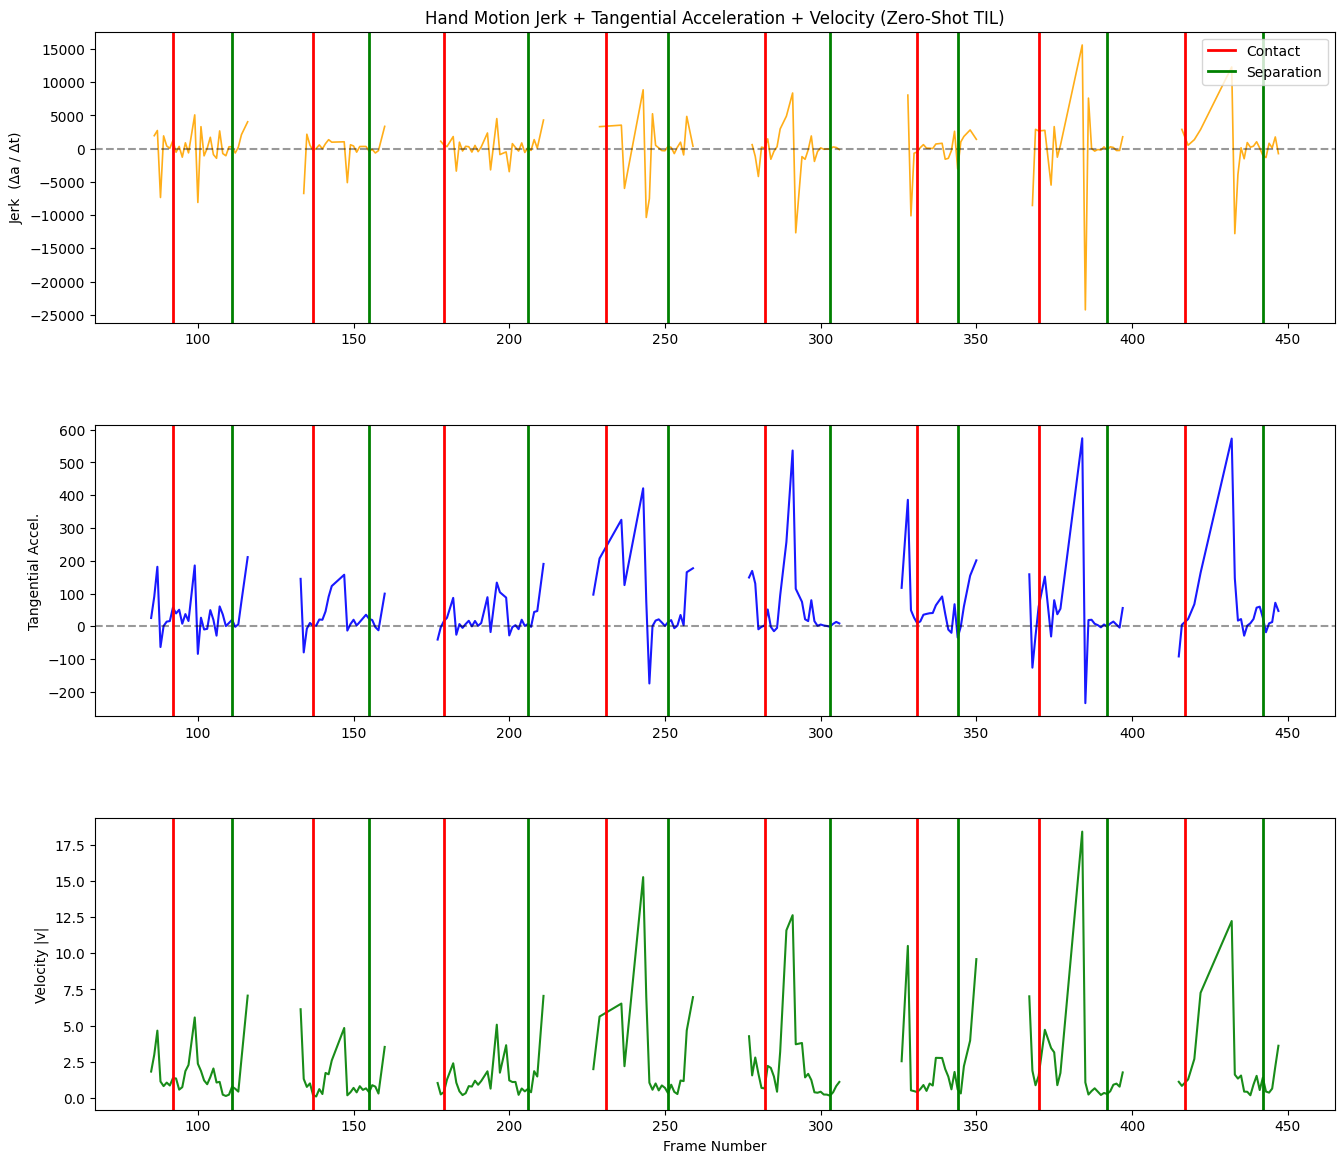

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re


# ----------  File-parsing helpers  ----------

def parse_landmarks_file(filename):
    landmarks_data = {}
    with open(filename, "r") as f:
        txt = f.read()
    blocks = re.split(r"(\d+):", txt)
    for i in range(1, len(blocks), 2):
        fr = int(blocks[i])
        blk = blocks[i + 1]
        x = float(re.search(r"x:\s*([-+]?\d*\.?\d+)", blk).group(1))
        y = float(re.search(r"y:\s*([-+]?\d*\.?\d+)", blk).group(1))
        z = float(re.search(r"z:\s*([-+]?\d*\.?\d+)", blk).group(1))
        landmarks_data[fr] = {"x": x, "y": y, "z": z}
    return landmarks_data


def parse_clip_ranges(filename):
    clips = []
    with open(filename) as f:
        for ln, line in enumerate(f, 1):
            m = re.search(r"\d+\.\s*(\d+),\s*(\d+)", line.strip())
            if m:
                clips.append((int(m.group(1)), int(m.group(2))))
            elif line.strip():
                print(f"Warning: cannot parse clip-range line {ln}: {line.strip()}")
    return clips


def parse_cs_annot(filename):
    cs = []
    with open(filename) as f:
        for ln, line in enumerate(f, 1):
            m = re.search(r"\d+\.\s*(\d+),\s*(\d+)", line.strip())
            if m:
                cs.append((int(m.group(1)), int(m.group(2))))
            elif line.strip():
                print(f"Warning: cannot parse cs-annot line {ln}: {line.strip()}")
    return cs


# ----------  Kinematic primitives  ----------

def calc_tangential_accel(landmarks, fps=30):
    if len(landmarks) < 3:
        return [], []
    pos = np.array([[p["x"], p["y"], p["z"]] for p in landmarks])
    dt = 1.0 / fps
    vel = np.diff(pos, axis=0) / dt
    acc = np.diff(vel, axis=0) / dt
    vel_mag = np.linalg.norm(vel[1:], axis=1)

    a_tan = []
    for i in range(len(acc)):
        v = vel[i + 1]
        a = acc[i]
        v_norm = np.linalg.norm(v)
        a_tan.append(np.dot(a, v) / v_norm if v_norm > 1e-10 else 0.0)
    return a_tan, vel_mag.tolist()


def compute_jerk(accel, fps=30):
    """accel = list of tangential-acceleration samples (aligned with frames[2:])."""
    if len(accel) < 2:
        return []
    dt = 1.0 / fps
    jerk = np.diff(accel) / dt
    return jerk.tolist()          # aligned to frames[3:]


# ----------  Per-clip processing  ----------

def process_landmarks_by_clips(lm_data, clip_ranges, fps=30):
    clip_data = []
    for idx, (s, e) in enumerate(clip_ranges):
        fr_list = [f for f in sorted(lm_data) if s <= f <= e]
        lm_list = [lm_data[f] for f in fr_list]
        print(f"Clip {idx+1} ({s}-{e}): {len(lm_list)} landmark frames")
        if len(lm_list) < 3:
            print("   ⚠️  Not enough frames for kinematics")
            continue

        a_tan, vel = calc_tangential_accel(lm_list, fps)
        jerk = compute_jerk(a_tan, fps)

        # Frame alignment
        accel_frames = fr_list[2:]
        jerk_frames  = fr_list[3:]  # one frame later than accel

        clip_data.append(
            {
                "frames": accel_frames,
                "accelerations": a_tan,
                "velocities": vel,
                "jerk_frames": jerk_frames,
                "jerks": jerk,
                "clip_range": (s, e)
            }
        )
    return clip_data


# ----------  Visualization  ----------

def plot_accel_velocity_jerk(clip_data, cs_annots):
    fig = plt.figure(figsize=(16, 14))
    gs  = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=0.35)
    axJ = fig.add_subplot(gs[0])
    axA = fig.add_subplot(gs[1], sharex=axJ)
    axV = fig.add_subplot(gs[2], sharex=axJ)

    # 1) Jerk (orange)
    for c in clip_data:
        axJ.plot(c["jerk_frames"], c["jerks"], color="orange", lw=1.2, alpha=0.9)
    axJ.axhline(0, ls="--", c="k", alpha=0.4)
    axJ.set_ylabel("Jerk  (Δa / Δt)")
    axJ.set_title("Hand Motion Jerk + Tangential Acceleration + Velocity (Zero-Shot TIL)")

    # 2) Tangential acceleration (blue)
    for c in clip_data:
        axA.plot(c["frames"], c["accelerations"], color="blue", lw=1.5, alpha=0.9)
    axA.axhline(0, ls="--", c="k", alpha=0.4)
    axA.set_ylabel("Tangential Accel.")

    # 3) Velocity magnitude (green)
    for c in clip_data:
        axV.plot(c["frames"], c["velocities"], color="green", lw=1.5, alpha=0.9)
    axV.set_ylabel("Velocity |v|")
    axV.set_xlabel("Frame Number")

    # === Contact / Separation lines on all three axes
    lab_c_added = lab_s_added = False
    for (contact, sep) in cs_annots[: len(clip_data)]:
        for ax in (axJ, axA, axV):
            if not lab_c_added and ax is axJ:
                ax.axvline(contact, c="red", lw=2, label="Contact")
                lab_c_added = True
            else:
                ax.axvline(contact, c="red", lw=2)
            if not lab_s_added and ax is axJ:
                ax.axvline(sep, c="green", lw=2, label="Separation")
                lab_s_added = True
            else:
                ax.axvline(sep, c="green", lw=2)

    axJ.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    return fig


# ----------  Main  ----------

def main():
    landmarks_file   = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    cs_annot_file    = "../test_data/cs_annot.txt"

    lm   = parse_landmarks_file(landmarks_file)
    clips = parse_clip_ranges(clip_ranges_file)
    cs   = parse_cs_annot(cs_annot_file)

    clip_data = process_landmarks_by_clips(lm, clips, fps=30)
    plot_accel_velocity_jerk(clip_data, cs)


if __name__ == "__main__":
    main()
